In [130]:
# Urinalysis Analysis & Issue Detection

## Objective
# Build a data-driven module that analyzes urine test results and detects potential health issues such as:
# - Urinary Tract Infection (UTI)
# - Kidney Issues
# - Diabetes Risk
# - Normal cases

# This model will be part of a larger healthcare system.

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
df = pd.read_csv("urinalysis_tests (1).csv")
df.head()

,Unnamed: 0,Age,Gender,Color,Transparency,Glucose,Protein,pH,Specific Gravity,WBC,RBC,Epithelial Cells,Mucous Threads,Amorphous Urates,Bacteria,Diagnosis
0,0,76.0,FEMALE,LIGHT YELLOW,CLEAR,NEGATIVE,NEGATIVE,5.0,1.010,1-3,0-2,OCCASIONAL,RARE,NONE SEEN,OCCASIONAL,NEGATIVE
1,1,9.0,MALE,DARK YELLOW,SLIGHTLY HAZY,NEGATIVE,1+,5.0,1.030,1-3,0-2,RARE,FEW,FEW,MODERATE,NEGATIVE
2,2,12.0,MALE,LIGHT YELLOW,SLIGHTLY HAZY,NEGATIVE,TRACE,5.0,1.030,0-3,0-2,RARE,FEW,MODERATE,RARE,NEGATIVE
3,3,77.0,MALE,BROWN,CLOUDY,NEGATIVE,1+,6.0,1.020,5-8,LOADED,RARE,RARE,NONE SEEN,FEW,NEGATIVE
4,4,29.0,FEMALE,YELLOW,HAZY,NEGATIVE,TRACE,6.0,1.025,1-4,0-2,RARE,RARE,NONE SEEN,FEW,NEGATIVE


In [133]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1436 non-null   int64  
 1   Age               1436 non-null   float64
 2   Gender            1436 non-null   object 
 3   Color             1435 non-null   object 
 4   Transparency      1436 non-null   object 
 5   Glucose           1436 non-null   object 
 6   Protein           1436 non-null   object 
 7   pH                1436 non-null   float64
 8   Specific Gravity  1436 non-null   float64
 9   WBC               1436 non-null   object 
 10  RBC               1436 non-null   object 
 11  Epithelial Cells  1436 non-null   object 
 12  Mucous Threads    1436 non-null   object 
 13  Amorphous Urates  1436 non-null   object 
 14  Bacteria          1436 non-null   object 
 15  Diagnosis         1436 non-null   object 
dtypes: float64(3), int64(1), object(12)
memory

,Unnamed: 0,Age,Gender,Color,Transparency,Glucose,Protein,pH,Specific Gravity,WBC,RBC,Epithelial Cells,Mucous Threads,Amorphous Urates,Bacteria,Diagnosis
count,1436.000000,1436.000000,1436,1435,1436,1436,1436,1436.000000,1436.000000,1436,1436,1436,1436,1436,1436,1436
unique,NaN,NaN,2,10,5,6,5,NaN,NaN,75,53,7,6,6,6,2
top,NaN,NaN,FEMALE,YELLOW,CLEAR,NEGATIVE,NEGATIVE,NaN,NaN,0-2,0-2,RARE,NONE SEEN,NONE SEEN,RARE,NEGATIVE
freq,NaN,NaN,816,710,1124,1349,804,NaN,NaN,448,618,742,500,1284,755,1355
mean,717.500000,27.207521,NaN,NaN,NaN,NaN,NaN,6.052925,1.015850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,414.681806,23.460032,NaN,NaN,NaN,NaN,NaN,0.598475,0.007285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.010000,NaN,NaN,NaN,NaN,NaN,5.000000,1.005000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,358.750000,6.000000,NaN,NaN,NaN,NaN,NaN,6.000000,1.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,717.500000,23.000000,NaN,NaN,NaN,NaN,NaN,6.000000,1.015000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1076.250000,45.000000,NaN,NaN,NaN,NaN,NaN,6.500000,1.020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Gender              0
Color               1
Transparency        0
Glucose             0
Protein             0
pH                  0
Specific Gravity    0
WBC                 0
RBC                 0
Epithelial Cells    0
Mucous Threads      0
Amorphous Urates    0
Bacteria            0
Diagnosis           0
dtype: int64

In [135]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [136]:
df.head()

,Age,Gender,Color,Transparency,Glucose,Protein,pH,Specific Gravity,WBC,RBC,Epithelial Cells,Mucous Threads,Amorphous Urates,Bacteria,Diagnosis
0,76.0,FEMALE,LIGHT YELLOW,CLEAR,NEGATIVE,NEGATIVE,5.0,1.010,1-3,0-2,OCCASIONAL,RARE,NONE SEEN,OCCASIONAL,NEGATIVE
1,9.0,MALE,DARK YELLOW,SLIGHTLY HAZY,NEGATIVE,1+,5.0,1.030,1-3,0-2,RARE,FEW,FEW,MODERATE,NEGATIVE
2,12.0,MALE,LIGHT YELLOW,SLIGHTLY HAZY,NEGATIVE,TRACE,5.0,1.030,0-3,0-2,RARE,FEW,MODERATE,RARE,NEGATIVE
3,77.0,MALE,BROWN,CLOUDY,NEGATIVE,1+,6.0,1.020,5-8,LOADED,RARE,RARE,NONE SEEN,FEW,NEGATIVE
4,29.0,FEMALE,YELLOW,HAZY,NEGATIVE,TRACE,6.0,1.025,1-4,0-2,RARE,RARE,NONE SEEN,FEW,NEGATIVE


In [137]:
df = df.applymap(lambda x: x.strip().upper() if isinstance(x, str) else x)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7476\584718316.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip().upper() if isinstance(x, str) else x)


In [138]:
df.columns = df.columns.str.strip().str.lower()

In [139]:
map_levels = {
    "NEGATIVE": 0,
    "TRACE": 1,
    "1+": 2,
    "2+": 3,
    "3+": 4
}

df["glucose"] = df["glucose"].map(map_levels)
df["protein"] = df["protein"].map(map_levels)

In [140]:
def convert_range(val):
    if isinstance(val, str):
        if "LOADED" in val:
            return 20
        elif "-" in val:
            low, high = val.split("-")
            return (int(low) + int(high)) / 2
    return 0

df["wbc"] = df["wbc"].apply(convert_range)
df["rbc"] = df["rbc"].apply(convert_range)

In [141]:
map_freq = {
    "NONE SEEN": 0,
    "RARE": 1,
    "FEW": 2,
    "MODERATE": 3,
    "MANY": 4,
    "OCCASIONAL": 2
}

cols = ["bacteria", "epithelial cells", "mucous threads", "amorphous urates"]

for col in cols:
    df[col] = df[col].map(map_freq)

In [142]:
df.head()

,age,gender,color,transparency,glucose,protein,ph,specific gravity,wbc,rbc,epithelial cells,mucous threads,amorphous urates,bacteria,diagnosis
0,76.0,FEMALE,LIGHT YELLOW,CLEAR,0.0,0,5.0,1.010,2.0,1.0,2.0,1.0,0.0,2.0,NEGATIVE
1,9.0,MALE,DARK YELLOW,SLIGHTLY HAZY,0.0,2,5.0,1.030,2.0,1.0,1.0,2.0,2.0,3.0,NEGATIVE
2,12.0,MALE,LIGHT YELLOW,SLIGHTLY HAZY,0.0,1,5.0,1.030,1.5,1.0,1.0,2.0,3.0,1.0,NEGATIVE
3,77.0,MALE,BROWN,CLOUDY,0.0,2,6.0,1.020,6.5,20.0,1.0,1.0,0.0,2.0,NEGATIVE
4,29.0,FEMALE,YELLOW,HAZY,0.0,1,6.0,1.025,2.5,1.0,1.0,1.0,0.0,2.0,NEGATIVE


In [143]:
df = df[df["gender"] == "FEMALE"]
df.drop(columns=["gender"], inplace=True)

In [144]:
df = df[(df["age"] >= 15) & (df["age"] <= 45)]

In [145]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[15, 25, 35, 45],
    labels=["Young", "Optimal", "High Risk"]
)

In [146]:
df = pd.get_dummies(df, columns=["color", "transparency"], drop_first=True)

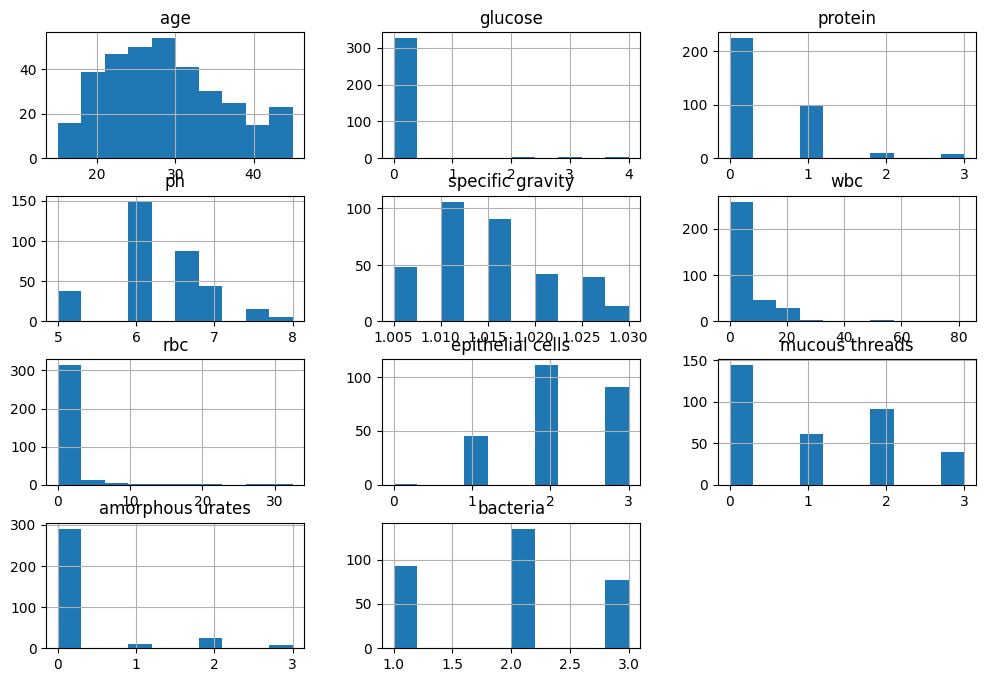

In [147]:
df.hist(figsize=(12,8))
plt.show()

In [148]:
age_map = {"Young": 0, "Optimal": 1, "High Risk": 2}
df["Age_Encoded"] = df["Age_Group"].map(age_map)


df.drop(columns=["age", "Age_Group"], inplace=True)

In [149]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))


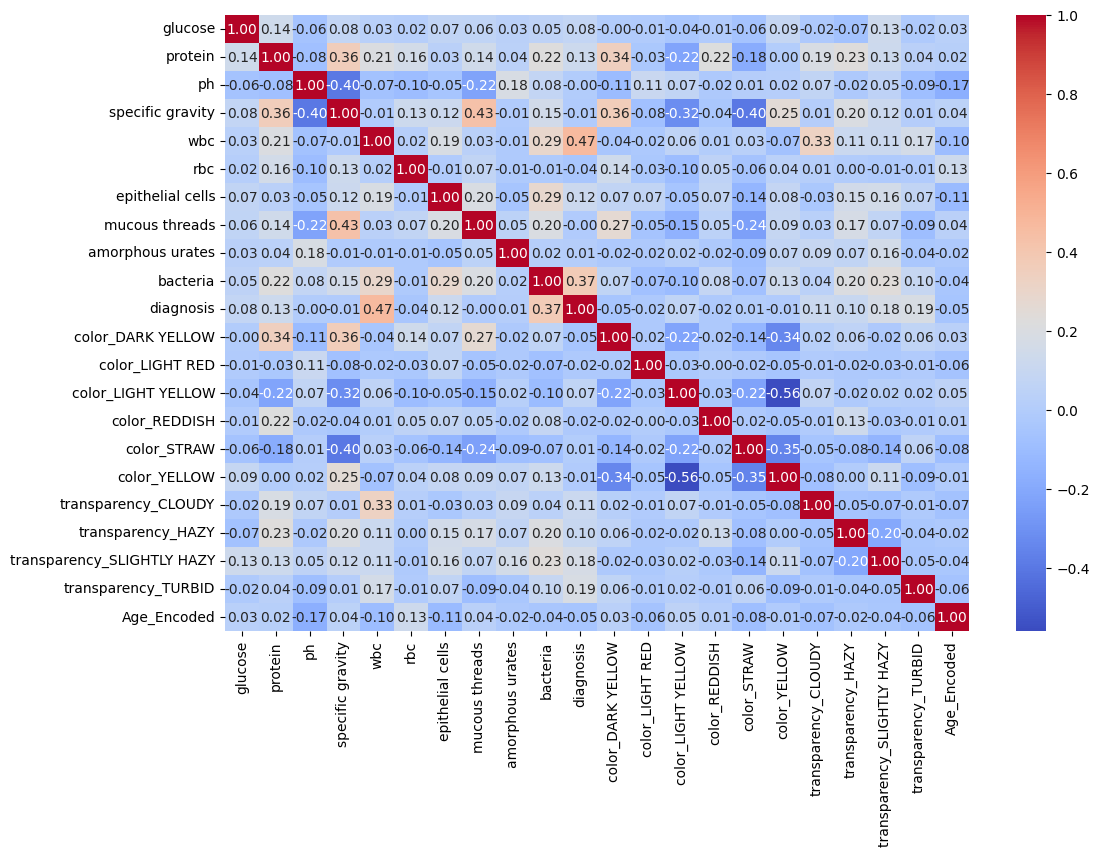

In [150]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [151]:
df["diagnosis"].value_counts()

diagnosis
0    309
1     31
Name: count, dtype: int64

In [152]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [154]:
from sklearn.tree import DecisionTreeClassifier

ml_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

ml_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [155]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = ml_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        62
           1       0.75      0.50      0.60         6

    accuracy                           0.94        68
   macro avg       0.85      0.74      0.78        68
weighted avg       0.94      0.94      0.94        68



In [156]:
def rule_based_system(row):

    # UTI
    if row["bacteria"] >= 3 and row["wbc"] > 5:
        return "UTI"

    # Kidney issue
    elif row["protein"] >= 2 and row["rbc"] > 5:
        return "Kidney Issue"

    # Diabetes risk
    elif row["glucose"] >= 2:
        return "Diabetes Risk"

    # Proteinuria warning (important for pregnancy context)
    elif row["protein"] >= 2:
        return "Proteinuria Warning"

    else:
        return "Normal"

In [157]:
def hybrid_predict(row):

    rule_result = rule_based_system(row)

    ml_result = ml_model.predict([row.values])[0]

    ml_proba = ml_model.predict_proba([row.values]).max()

    return {
        "rule_based_result": rule_result,
        "ml_result": ml_result,
        "ml_confidence": ml_proba
    }

In [158]:
df = df[ml_model.feature_names_in_]

In [159]:
import joblib

joblib.dump(ml_model, "ml_model.pkl")

['ml_model.pkl']

In [160]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']